# Prototyping Notebook

Scratch notebook for trying ideas out before they move into the main codebase. It covers:

1. Setup
2. Ground truth: RGB vs. IR annotations
3. Input resolution (256 × 256)
4. CrossFuse pipeline on a single image pair
5. Image degradation
6. Patch-level quality ground truth

## 1. Setup

Shared imports. CrossFuse and the quality estimator package are added to `sys.path` in the sections that use them.

In [1]:
import os
import sys
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.autograd import Variable

/home/tegan/miniconda3/envs/pace/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Ground truth: RGB vs. IR

The RGB and IR annotations for the same scene are not identical. Before using either as a target, plot both and see how they differ.

### 2.1 Loading and drawing annotations

The XML files store each object as a four-point polygon. `load_gt_boxes` reduces each polygon to its enclosing axis-aligned box, and `plot_gt` draws the boxes and class labels on the image.

In [2]:
BORDER_PIXELS = 100  # Number of pixels to remove from each side of the image

In [3]:
def apply_image_crop(image):
    """
    Crop out the borders of a given image
    """
    h, w = image.shape[:2]

    # Crop the image by slicing the array [ymin:ymax, xmin:xmax]
    cropped_image = image[BORDER_PIXELS:h - BORDER_PIXELS, BORDER_PIXELS:w - BORDER_PIXELS]

    return cropped_image

def load_gt_boxes(xml_path):
    """
    Load ground-truth polygons from the XML and convert them
    to axis-aligned bounding boxes.

    Returns:
        List of dictionaries containing:
        x1, y1, x2, y2, class_name
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        polygon = obj.find("polygon")

        # Get the four polygon points
        points = []
        for i in range(1, 5):
            x = int(float(polygon.find(f"x{i}").text))
            y = int(float(polygon.find(f"y{i}").text))
            points.append((x, y))

        # Convert polygon to enclosing bounding box
        xs = [point[0] for point in points]
        ys = [point[1] for point in points]

        boxes.append({
            "x1": min(xs),
            "y1": min(ys),
            "x2": max(xs),
            "y2": max(ys),
            "class_name": class_name,
        })

    return boxes


def draw_box(image, box, color, thickness=2):
    """Draw a bounding box and its class label on the image (in place)."""
    x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]

    cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(
        image, box["class_name"], (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1,
    )


def plot_gt(image_path, xml_path):
    """
    Load an image and XML ground truth, draw bounding boxes
    and labels, and return the image.
    """
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # Convert BGR -> RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for box in load_gt_boxes(xml_path):
        draw_box(image, box, (0, 255, 0))

    return apply_image_crop(image)

### 2.2 Side-by-side view

Sample pair `00001`, reused in later sections.

In [4]:
rgb_image_path = "./test_images/00001_rgb.jpg"
rgb_xml_path = "./test_images/00001_rgb.xml"

ir_image_path = "./test_images/00001_ir.jpg"
ir_xml_path = "./test_images/00001_ir.xml"

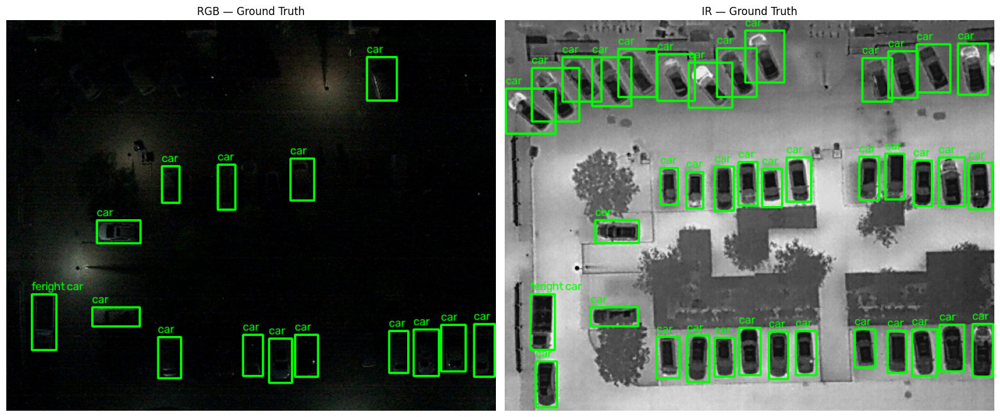

In [5]:
rgb_image = plot_gt(rgb_image_path, rgb_xml_path)
ir_image = plot_gt(ir_image_path, ir_xml_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(rgb_image)
axes[0].set_title("RGB — Ground Truth")
axes[0].axis("off")

axes[1].imshow(ir_image)
axes[1].set_title("IR — Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 2.3 Highlighting the differences

Boxes are matched between the two modalities greedily. For each RGB box, take the unmatched IR box of the same class with the highest IoU and accept it if the IoU reaches the threshold (0.5). Matched boxes are drawn in green and unmatched boxes in red.

In [6]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two boxes.
    Boxes are dictionaries with x1, y1, x2, y2.
    """
    x1 = max(box1["x1"], box2["x1"])
    y1 = max(box1["y1"], box2["y1"])
    x2 = min(box1["x2"], box2["x2"])
    y2 = min(box1["y2"], box2["y2"])

    intersection_width = max(0, x2 - x1)
    intersection_height = max(0, y2 - y1)
    intersection = intersection_width * intersection_height

    area1 = (box1["x2"] - box1["x1"]) * (box1["y2"] - box1["y1"])
    area2 = (box2["x2"] - box2["x1"]) * (box2["y2"] - box2["y1"])

    union = area1 + area2 - intersection

    if union == 0:
        return 0

    return intersection / union


def match_boxes(rgb_boxes, ir_boxes, iou_threshold=0.5):
    """
    Match each RGB box to the best unmatched IR box of the same class.

    Returns:
        matched_pairs: list of dicts with rgb_idx, ir_idx, iou
        rgb_only: indices of RGB boxes with no IR match
        ir_only: indices of IR boxes that were never matched
    """
    matched_ir = set()
    matched_pairs = []
    rgb_only = []

    for rgb_idx, rgb_box in enumerate(rgb_boxes):
        best_iou = 0
        best_ir_idx = None

        for ir_idx, ir_box in enumerate(ir_boxes):
            if ir_idx in matched_ir:
                continue

            # Only compare boxes of the same class
            if rgb_box["class_name"] != ir_box["class_name"]:
                continue

            iou = calculate_iou(rgb_box, ir_box)

            if iou > best_iou:
                best_iou = iou
                best_ir_idx = ir_idx

        if best_ir_idx is not None and best_iou >= iou_threshold:
            matched_ir.add(best_ir_idx)
            matched_pairs.append({
                "rgb_idx": rgb_idx,
                "ir_idx": best_ir_idx,
                "iou": best_iou,
            })
        else:
            rgb_only.append(rgb_idx)

    ir_only = [i for i in range(len(ir_boxes)) if i not in matched_ir]

    return matched_pairs, rgb_only, ir_only

In [7]:
def draw_matches(image, boxes, unmatched):
    """Draw matched boxes in green and unmatched boxes in red."""
    for idx, box in enumerate(boxes):
        if idx in unmatched:
            draw_box(image, box, (255, 0, 0), 3)
        else:
            draw_box(image, box, (0, 255, 0), 2)


def print_heading(title):
    print("\n" + "-" * 60)
    print(title)
    print("-" * 60)


def print_unmatched(tag, boxes, indices):
    for idx in indices:
        box = boxes[idx]
        print(
            f"{tag} [{idx}] | "
            f"Label: {box['class_name']} | "
            f"Box: ({box['x1']}, {box['y1']}) → "
            f"({box['x2']}, {box['y2']})"
        )


def print_report(rgb_boxes, ir_boxes, matched_pairs, rgb_only, ir_only):
    print("=" * 60)
    print("RGB ↔ IR GROUND TRUTH COMPARISON")
    print("=" * 60)

    print(f"\nRGB GT objects: {len(rgb_boxes)}")
    print(f"IR GT objects:  {len(ir_boxes)}")

    print(f"\nMatched objects: {len(matched_pairs)}")
    print(f"RGB-only objects: {len(rgb_only)}")
    print(f"IR-only objects:  {len(ir_only)}")

    print_heading("MATCHED OBJECTS")
    for pair in matched_pairs:
        rgb_idx = pair["rgb_idx"]
        ir_idx = pair["ir_idx"]

        print(
            f"RGB [{rgb_idx}] ↔ IR [{ir_idx}] | "
            f"Label: {rgb_boxes[rgb_idx]['class_name']} | "
            f"IoU: {pair['iou']:.3f}"
        )

    print_heading("RGB-ONLY OBJECTS")
    print_unmatched("RGB", rgb_boxes, rgb_only)

    print_heading("IR-ONLY OBJECTS")
    print_unmatched("IR", ir_boxes, ir_only)


def compare_rgb_ir_gt(rgb_image_path, rgb_xml_path, ir_image_path, ir_xml_path,
                      iou_threshold=0.5):
    rgb_image = cv2.imread(rgb_image_path)
    ir_image = cv2.imread(ir_image_path)

    if rgb_image is None:
        raise FileNotFoundError(f"Could not load RGB image: {rgb_image_path}")

    if ir_image is None:
        raise FileNotFoundError(f"Could not load IR image: {ir_image_path}")

    # Convert BGR -> RGB for matplotlib
    rgb_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB)
    ir_image = cv2.cvtColor(ir_image, cv2.COLOR_BGR2RGB)

    rgb_boxes = load_gt_boxes(rgb_xml_path)
    ir_boxes = load_gt_boxes(ir_xml_path)

    matched_pairs, rgb_only, ir_only = match_boxes(rgb_boxes, ir_boxes, iou_threshold)

    draw_matches(rgb_image, rgb_boxes, rgb_only)
    draw_matches(ir_image, ir_boxes, ir_only)

    print_report(rgb_boxes, ir_boxes, matched_pairs, rgb_only, ir_only)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].imshow(apply_image_crop(rgb_image))
    axes[0].set_title("RGB Ground Truth\nGreen: Matched | Red: RGB-only")
    axes[0].axis("off")

    axes[1].imshow(apply_image_crop(ir_image))
    axes[1].set_title("IR Ground Truth\nGreen: Matched | Red: IR-only")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

Run the comparison on the sample pair. The report lists the matched boxes and the boxes that only appear in one modality.

RGB ↔ IR GROUND TRUTH COMPARISON

RGB GT objects: 15
IR GT objects:  39

Matched objects: 15
RGB-only objects: 0
IR-only objects:  24

------------------------------------------------------------
MATCHED OBJECTS
------------------------------------------------------------
RGB [0] ↔ IR [1] | Label: feright car | IoU: 1.000
RGB [1] ↔ IR [2] | Label: car | IoU: 1.000
RGB [2] ↔ IR [3] | Label: car | IoU: 1.000
RGB [3] ↔ IR [7] | Label: car | IoU: 0.674
RGB [4] ↔ IR [10] | Label: car | IoU: 1.000
RGB [5] ↔ IR [11] | Label: car | IoU: 1.000
RGB [6] ↔ IR [12] | Label: car | IoU: 1.000
RGB [7] ↔ IR [13] | Label: car | IoU: 1.000
RGB [8] ↔ IR [14] | Label: car | IoU: 1.000
RGB [9] ↔ IR [15] | Label: car | IoU: 0.882
RGB [10] ↔ IR [35] | Label: car | IoU: 0.764
RGB [11] ↔ IR [17] | Label: car | IoU: 0.848
RGB [12] ↔ IR [20] | Label: car | IoU: 0.811
RGB [13] ↔ IR [6] | Label: car | IoU: 0.730
RGB [14] ↔ IR [8] | Label: car | IoU: 0.802

-----------------------------------------------------------

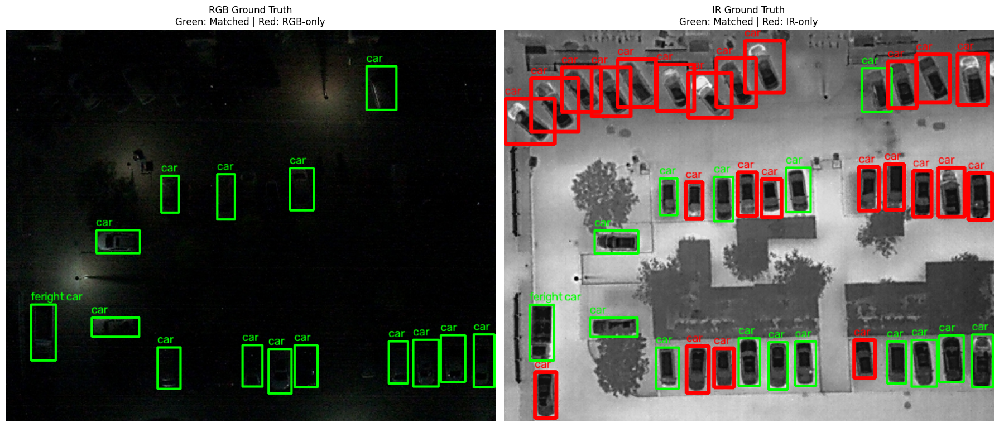

In [8]:
compare_rgb_ir_gt(
    rgb_image_path,
    rgb_xml_path,
    ir_image_path,
    ir_xml_path,
    iou_threshold=0.5,
)

## 3. Input resolution

Resize the sample pair to 256 × 256 (grayscale) and compare against the originals.

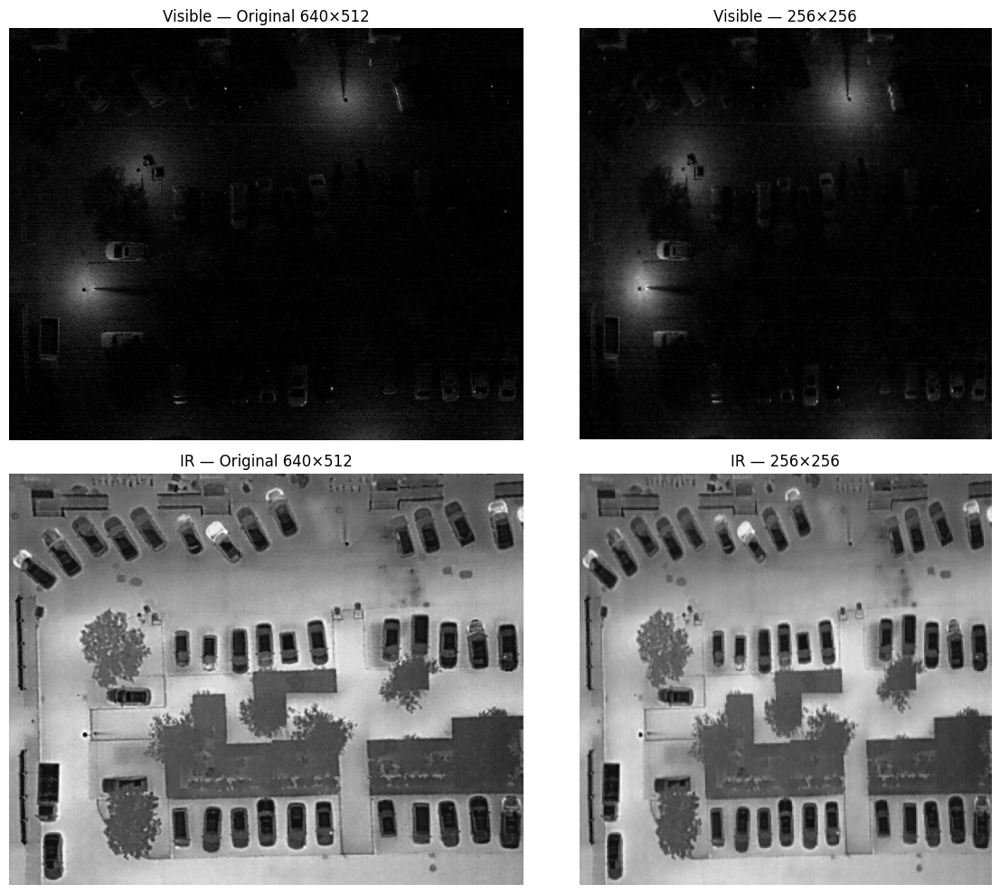

In [9]:
rgb = apply_image_crop(cv2.imread(str(rgb_image_path), cv2.IMREAD_GRAYSCALE))
ir = apply_image_crop(cv2.imread(str(ir_image_path), cv2.IMREAD_GRAYSCALE))

rgb_256 = cv2.resize(rgb, (256, 256))
ir_256 = cv2.resize(ir, (256, 256))

panels = [
    (rgb, f"Visible — Original {rgb.shape[1]}×{rgb.shape[0]}"),
    (rgb_256, "Visible — 256×256"),
    (ir, f"IR — Original {ir.shape[1]}×{ir.shape[0]}"),
    (ir_256, "IR — 256×256"),
]

plt.figure(figsize=(12, 10))

for i, (image, title) in enumerate(panels, start=1):
    plt.subplot(2, 2, i)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

The resized images look reasonable, the paper uses 256 × 256, and it makes the computations faster. A lot of detail is lost though, so the next step is to check whether that is acceptable or whether the resolution should go up.

## 4. CrossFuse pipeline

Walk through the CrossFuse baseline to see how it works and how to run it on a single image pair. The code is adapted from `test_color_image.py` in the CrossFuse repo.

### 4.1 Imports and paths

CrossFuse is not installed as a package, so its folder is added to `sys.path` before importing from it.

In [10]:
# PACE/
REPO_ROOT = Path.cwd().parent

# PACE/baseline/CrossFuse/
CROSSFUSE_ROOT = REPO_ROOT / "baseline" / "CrossFuse"

# Add CrossFuse to Python's import path
sys.path.insert(0, str(CROSSFUSE_ROOT))

from network.net_autoencoder import Auto_Encoder_single
from network.net_conv_trans import Trans_FuseNet
from tools import utils

### 4.2 Settings

Device, class names, input pair, pretrained weights, the CrossFuse shift flag and the detection threshold.

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["car", "truck", "bus", "van", "freight_car"]

# Single input pair
ir_path = str(REPO_ROOT / "prototyping" / "test_images" / "00001_ir.jpg")
vi_path = str(REPO_ROOT / "prototyping" / "test_images" / "00001_rgb.jpg")

# Model weights
model_path_auto_ir = str(
    CROSSFUSE_ROOT / "models" / "autoencoder" / "OLD" / "auto_encoder_epoch_4_ir.model"
)
model_path_auto_vi = str(
    CROSSFUSE_ROOT / "models" / "autoencoder" / "OLD" / "auto_encoder_epoch_4_vi.model"
)
model_path_trans = str(
    CROSSFUSE_ROOT / "models" / "transfuse"
    / "fusetrans_epoch_32_bs_8_num_20k_lr_0.1_s1_c1.model"
)

# CrossFuse setting
shift_flag = True

# Detection threshold
detection_threshold = 0.5

### 4.3 Model configuration

The IR and visible autoencoders share one configuration. The fusion transformer has its own.

In [12]:
custom_config_auto = {
    "in_channels": 1,
    "out_channels": 1,
    "en_out_channels1": 32,
    "en_out_channels": 64,
    "num_layers": 3,
    "dense_out": 128,
    "part_out": 128,
    "train_flag": False,
}

custom_config_trans = {
    "en_out_channels1": 32,
    "out_channels": 1,
    "part_out": 128,
    "train_flag": False,

    "img_size": 32,
    "patch_size": 2,
    "depth_self": 1,
    "depth_cross": 1,
    "n_heads": 16,
    "qkv_bias": True,
    "mlp_ratio": 4,
    "p": 0.,
    "attn_p": 0.,
}

### 4.4 Load models

Two autoencoders (IR and visible) and the fusion transformer, all put in eval mode. The transformer weights are loaded with `strict=False`.

In [13]:
def load_weights(model, weights_path, strict=True):
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE), strict=strict)
    model.to(DEVICE)
    model.eval()
    return model


model_auto_ir = load_weights(Auto_Encoder_single(**custom_config_auto), model_path_auto_ir)
model_auto_vi = load_weights(Auto_Encoder_single(**custom_config_auto), model_path_auto_vi)
model_trans = load_weights(Trans_FuseNet(**custom_config_trans), model_path_trans, strict=False)

print("Models loaded successfully.")
print("Device:", DEVICE)

Models loaded successfully.
Device: cpu


### 4.5 Load the image pair

`get_test_images_color` also returns the Cb and Cr components of the visible image. They are not used below.

In [14]:
# None, None keeps the original resolution.
# Delete both to resize to 256x256.
ir_img = utils.get_train_images(ir_path, None, None, flag=False)
vi_img, vi_cb, vi_cr = utils.get_test_images_color(vi_path, None, None, flag=True)

ir_img = Variable(ir_img, requires_grad=False).to(DEVICE)
vi_img = Variable(vi_img, requires_grad=False).to(DEVICE)

### 4.6 Inference

Each modality goes through its own autoencoder. The decoded and shared features from both are then passed to the fusion transformer, which returns a dict containing the fused features (`fused_features`), the fused image (`out`) and the detection map (`detections`).

In [15]:
with torch.no_grad():
    # Per-modality autoencoders
    ir_sh, ir_de = model_auto_ir(ir_img)
    vi_sh, vi_de = model_auto_vi(vi_img)

    # Transformer fusion + detection head
    outputs = model_trans(ir_de, ir_sh, vi_de, vi_sh, shift_flag)

In [16]:
print("\n========== MODEL OUTPUT ==========")
print("Fused feature shape:", outputs["fused_features"].shape)
print("Detection output shape:", outputs["detections"].shape)


========== MODEL OUTPUT ==========
Fused feature shape: torch.Size([1, 128, 89, 105])
Detection output shape: torch.Size([1, 10, 89, 105])


### 4.7 Decoding detections

The detection map has 10 channels per feature-map cell: objectness, box (x, y, w, h) and five class scores. `decode_detections` keeps the cells where objectness and the combined confidence (objectness × class score) both reach the threshold, then scales the normalized box centre and size to pixels and clamps the box to the image. There is no non-maximum suppression.

In [17]:
def decode_detections(detections, image_width, image_height, threshold=0.5):
    detections = detections[0]

    # Objectness
    objectness = torch.sigmoid(detections[0])

    # Bounding box coordinates
    x = torch.sigmoid(detections[1])
    y = torch.sigmoid(detections[2])
    w = torch.sigmoid(detections[3])
    h = torch.sigmoid(detections[4])

    # Class predictions
    class_scores = torch.softmax(detections[5:10], dim=0)

    feature_height = detections.shape[1]
    feature_width = detections.shape[2]

    boxes = []

    for row in range(feature_height):
        for col in range(feature_width):

            obj_confidence = objectness[row, col].item()

            if obj_confidence < threshold:
                continue

            # Most likely class
            class_score, class_id = torch.max(class_scores[:, row, col], dim=0)

            class_score = class_score.item()
            class_id = class_id.item()

            # Combined confidence
            confidence = obj_confidence * class_score

            if confidence < threshold:
                continue

            # Convert normalized coordinates to image coordinates
            center_x = x[row, col].item() * image_width
            center_y = y[row, col].item() * image_height
            box_width = w[row, col].item() * image_width
            box_height = h[row, col].item() * image_height

            x1 = int(center_x - box_width / 2)
            y1 = int(center_y - box_height / 2)

            x2 = int(center_x + box_width / 2)
            y2 = int(center_y + box_height / 2)

            # Clamp to image boundaries
            x1 = max(0, min(x1, image_width - 1))
            y1 = max(0, min(y1, image_height - 1))
            x2 = max(0, min(x2, image_width - 1))
            y2 = max(0, min(y2, image_height - 1))

            boxes.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "confidence": confidence,
                "class_id": class_id,
                "class_name": CLASS_NAMES[class_id],
            })

    return boxes

Decode against the size of the original visible image.

In [18]:
vi_original = cv2.imread(vi_path)

if vi_original is None:
    raise FileNotFoundError(f"Could not load VI image: {vi_path}")

image_height, image_width = vi_original.shape[:2]

boxes = decode_detections(
    outputs["detections"],
    image_width,
    image_height,
    threshold=detection_threshold,
)

print("\nNumber of detections:", len(boxes))

for i, box in enumerate(boxes):
    print(
        f"Detection {i + 1}: "
        f"{box['class_name']} "
        f"confidence={box['confidence']:.3f} "
        f"box=({box['x1']}, {box['y1']}, "
        f"{box['x2']}, {box['y2']})"
    )


Number of detections: 0


### 4.8 Visualizing the results

Top row: input IR, input visible and the fused output. Bottom row: the same three images with the decoded detections drawn on. The fused output is a normalized float image, so its box colour is given on a 0–1 scale.

In [19]:
def tensor_to_image(tensor):
    """
    Convert a CrossFuse output tensor into a numpy image
    suitable for matplotlib.
    """
    if isinstance(tensor, torch.Tensor):
        tensor = tensor.detach().cpu()

        # Remove batch dimension
        if tensor.dim() == 4:
            tensor = tensor[0]

        # CHW -> HWC
        if tensor.dim() == 3:
            if tensor.shape[0] in [1, 3]:
                tensor = tensor.permute(1, 2, 0)

        tensor = tensor.numpy()

    tensor = np.asarray(tensor)

    # Remove single channel dimension
    if tensor.ndim == 3 and tensor.shape[2] == 1:
        tensor = tensor[:, :, 0]

    # Normalize for visualization
    tensor_min = tensor.min()
    tensor_max = tensor.max()

    if tensor_max > tensor_min:
        tensor = (tensor - tensor_min) / (tensor_max - tensor_min)

    return tensor


def draw_detections(image, boxes, color):
    """Draw each detection box with its class name and confidence."""
    for box in boxes:
        x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]
        label = f"{box['class_name']} {box['confidence']:.2f}"

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            image, label, (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1,
        )

In [20]:
ir_original = cv2.imread(ir_path, cv2.IMREAD_GRAYSCALE)
vi_original = cv2.imread(vi_path, cv2.IMREAD_COLOR)

if ir_original is None:
    raise FileNotFoundError(f"Could not load IR image: {ir_path}")

if vi_original is None:
    raise FileNotFoundError(f"Could not load VI image: {vi_path}")

fused_image = tensor_to_image(outputs["out"])

# Copies to draw detections on
ir_detection = cv2.cvtColor(ir_original, cv2.COLOR_GRAY2RGB)
vi_detection = cv2.cvtColor(vi_original, cv2.COLOR_BGR2RGB)

# Resize fused image to match original VI dimensions
fused_display = cv2.resize(
    fused_image,
    (vi_original.shape[1], vi_original.shape[0]),
)

# Convert grayscale fused image to RGB for drawing
if fused_display.ndim == 2:
    fused_detection = np.stack([fused_display] * 3, axis=-1)
else:
    fused_detection = fused_display.copy()

draw_detections(ir_detection, boxes, (0, 255, 0))
draw_detections(vi_detection, boxes, (0, 255, 0))
draw_detections(fused_detection, boxes, (0, 1, 0))  # float image, so 0-1 scale

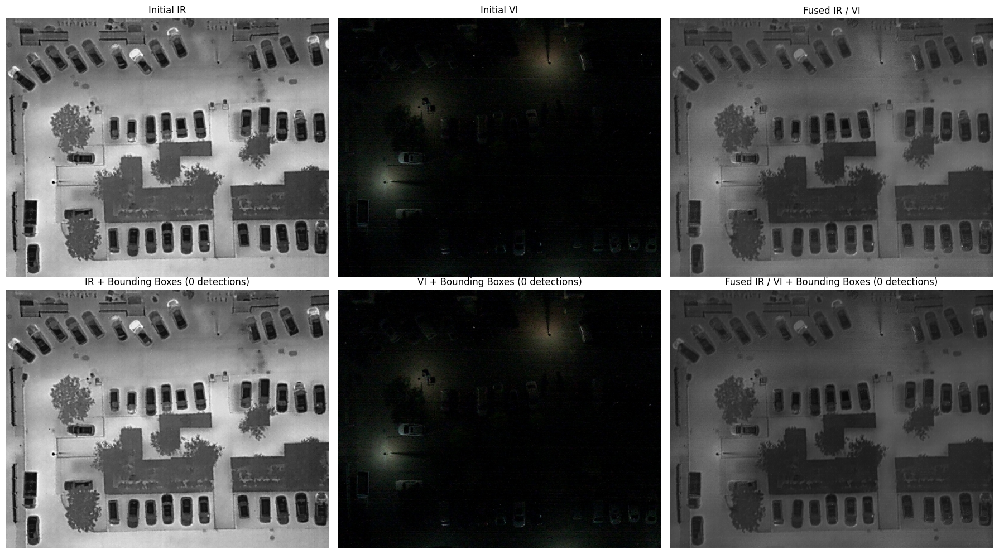

In [21]:
n = len(boxes)

panels = [
    (ir_original, "Initial IR", "gray"),
    (cv2.cvtColor(vi_original, cv2.COLOR_BGR2RGB), "Initial VI", None),
    (fused_image, "Fused IR / VI", "gray"),
    (ir_detection, f"IR + Bounding Boxes ({n} detections)", None),
    (vi_detection, f"VI + Bounding Boxes ({n} detections)", None),
    (fused_detection, f"Fused IR / VI + Bounding Boxes ({n} detections)", None),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (image, title, cmap) in zip(axes.flat, panels):
    ax.imshow(apply_image_crop(image), cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Image degradation

See what the different degradation methods look like on an RGB image, all at severity 1.0. This shows how each method behaves and what region its mask covers.

### 5.1 Imports and helpers

`apply_degradation` comes from `quality_estimator/synthetic_data_degradation/`, so the project root goes on `sys.path`. `draw_mask_boxes` outlines every connected region of a degradation mask in red (regions under 5 pixels are skipped) and `read_image_cropped` trims a border off the image.

In [22]:
# Make the project root importable
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from quality_estimator.synthetic_data_degradation.degradation import apply_degradation

In [23]:
def draw_mask_boxes(image, mask):
    """
    Draw a red bounding box around each separate masked region.
    """
    output = image.copy()

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8),
        connectivity=8,
    )

    for label in range(1, num_labels):
        x = stats[label, cv2.CC_STAT_LEFT]
        y = stats[label, cv2.CC_STAT_TOP]
        width = stats[label, cv2.CC_STAT_WIDTH]
        height = stats[label, cv2.CC_STAT_HEIGHT]
        area = stats[label, cv2.CC_STAT_AREA]

        # Ignore extremely small regions.
        if area < 5:
            continue

        cv2.rectangle(
            output,
            (x, y),
            (x + width - 1, y + height - 1),
            (0, 0, 255),
            2,
        )

    return output

### 5.2 Applying the degradations

Water blur, motion blur, sensor noise and saturation on the cropped RGB frame `00237`. Each call returns the degraded image and a metadata dict that includes the pixel mask and the severity.

In [24]:
input_image = apply_image_crop(cv2.imread("./test_images/00237_rgb.jpg", cv2.IMREAD_COLOR))

if input_image is None:
    raise ValueError(f"Could not load image: {ir_image_path}")

degradation_types = ["water_blur", "motion_blur", "sensor_noise", "saturation"]

degraded_images = {}
degraded_metadata = {}

for name in degradation_types:
    degraded_images[name], degraded_metadata[name] = apply_degradation(
        input_image,
        degradation_type=name,
        severity=1.0, # Using the highest severity for visualization, can adjust or make random
    )

# Outline the degraded regions in red
degraded_display = {
    name: draw_mask_boxes(degraded_images[name], degraded_metadata[name]["mask"])
    for name in degradation_types
}

The original next to each degraded version, with the masked regions outlined in red.

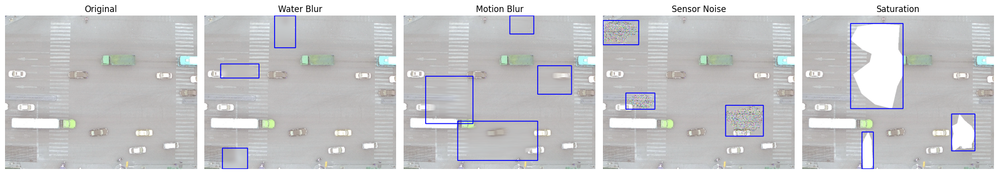

In [25]:
images = [input_image] + [degraded_display[name] for name in degradation_types]
titles = ["Original", "Water Blur", "Motion Blur", "Sensor Noise", "Saturation"]

plt.figure(figsize=(20, 10))

for index, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 5, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Patch-level quality ground truth

Ground truth for the quality estimator is a grid of per-patch scores (8 × 8 here) in [0, 1], where 1 is high quality. This section builds that ground truth and overlays it on the images to check it looks right.

### 6.1 Overlay helper

Both ground-truth sources below are checked with the same overlay. Each patch is tinted from red (low quality) to green (high quality), outlined, and labelled with its score. The two wrappers differ only in how strongly the tint is blended in.

In [26]:
def plot_patch_quality_overlay(image, quality, title, image_weight, heatmap_weight):
    """
    Overlay a patch quality grid onto an image and show it.

    Green = high quality
    Red = low quality
    """
    height, width = image.shape[:2]
    grid_h, grid_w = quality.shape

    # Convert image to RGB for matplotlib.
    if len(image.shape) == 2:
        display_image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        display_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Expand the quality grid to image size.
    quality_resized = cv2.resize(
        quality,
        (width, height),
        interpolation=cv2.INTER_NEAREST,
    )

    # Red/green quality map: 0 = red, 1 = green
    heatmap = np.zeros((height, width, 3), dtype=np.uint8)
    heatmap[:, :, 0] = ((1 - quality_resized) * 255).astype(np.uint8)
    heatmap[:, :, 1] = (quality_resized * 255).astype(np.uint8)

    # Blend heatmap with original image.
    overlay = cv2.addWeighted(display_image, image_weight, heatmap, heatmap_weight, 0)

    # Draw patch boundaries and quality values.
    patch_height = height / grid_h
    patch_width = width / grid_w

    for row in range(grid_h):
        for col in range(grid_w):
            x_start = int(col * patch_width)
            y_start = int(row * patch_height)
            x_end = int((col + 1) * patch_width)
            y_end = int((row + 1) * patch_height)

            cv2.rectangle(
                overlay,
                (x_start, y_start),
                (x_end, y_end),
                (255, 255, 255),
                1,
            )

            cv2.putText(
                overlay,
                f"{quality[row, col]:.2f}",
                (x_start + 5, y_start + 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 255, 255),
                1,
                cv2.LINE_AA,
            )

    plt.figure(figsize=(10, 8))
    plt.imshow(overlay)
    plt.title(title)
    plt.axis("off")
    plt.show()


def visualize_patch_quality(image, quality, title="Patch Quality"):
    """Overlay the patch quality grid for a degradation-based ground truth."""
    plot_patch_quality_overlay(image, quality, title, image_weight=0.85, heatmap_weight=0.10)


def visualize_low_light_quality(image, quality, title="Low-Light Patch Quality"):
    """Overlay the patch quality grid for the low-light ground truth."""
    plot_patch_quality_overlay(image, quality, title, image_weight=0.80, heatmap_weight=0.15)

### 6.2 From degradation masks

`mask_to_patch_quality` takes the fraction of each patch covered by the mask, scales it by the severity and subtracts it from 1. Scores are clipped to [0, 1].

In [27]:
def mask_to_patch_quality(mask, grid_size=(8, 8), severity=1.0):
    """
    Convert a pixel-level degradation mask into patch-level
    quality ground truth.

    Returns values in [0, 1], where 1 is high quality.
    """
    height, width = mask.shape

    grid_h, grid_w = grid_size

    patch_height = height / grid_h
    patch_width = width / grid_w

    quality = np.ones((grid_h, grid_w), dtype=np.float32)

    for row in range(grid_h):
        for col in range(grid_w):
            y_start = int(row * patch_height)
            y_end = int((row + 1) * patch_height)

            x_start = int(col * patch_width)
            x_end = int((col + 1) * patch_width)

            patch = mask[y_start:y_end, x_start:x_end]

            degradation_fraction = patch.mean()

            quality[row, col] = 1.0 - degradation_fraction * severity

    return np.clip(quality, 0.0, 1.0)

In [28]:
patch_quality_gt = {}

for name in degradation_types:
    patch_quality_gt[name] = mask_to_patch_quality(
        degraded_metadata[name]["mask"],
        grid_size=(8, 8),
        severity=degraded_metadata[name]["severity"],
    )

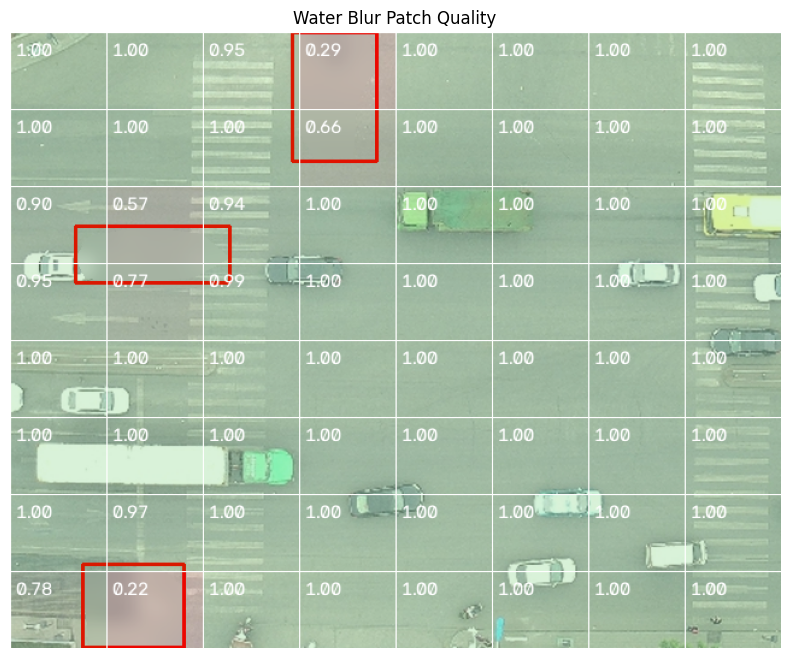

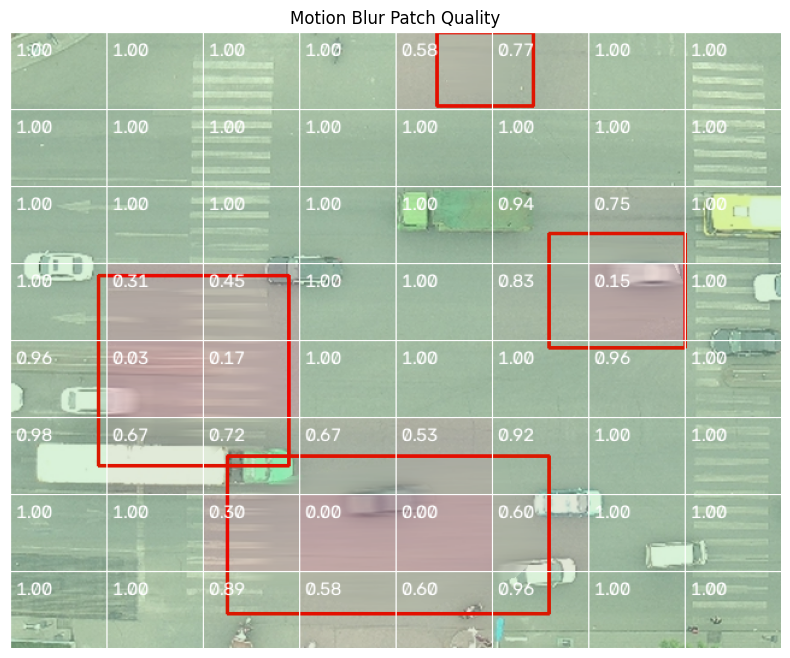

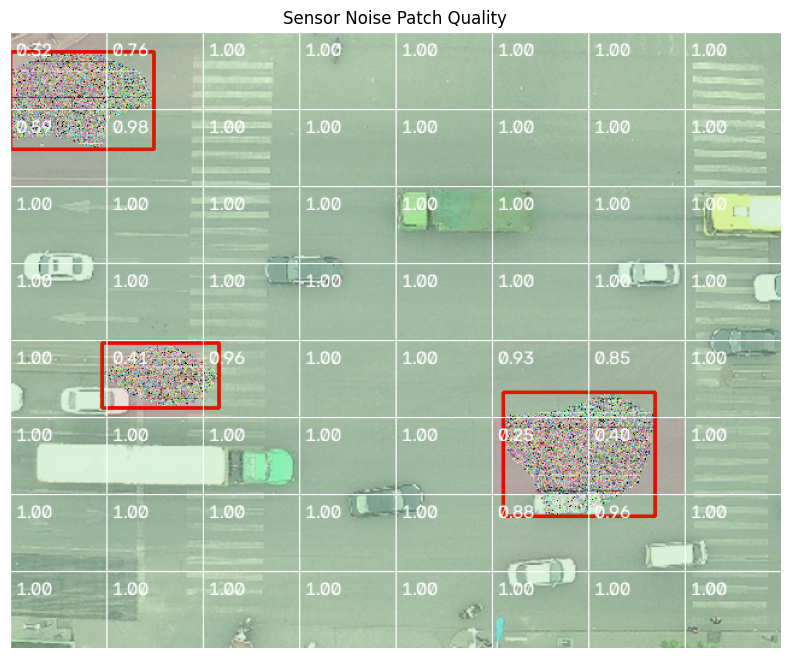

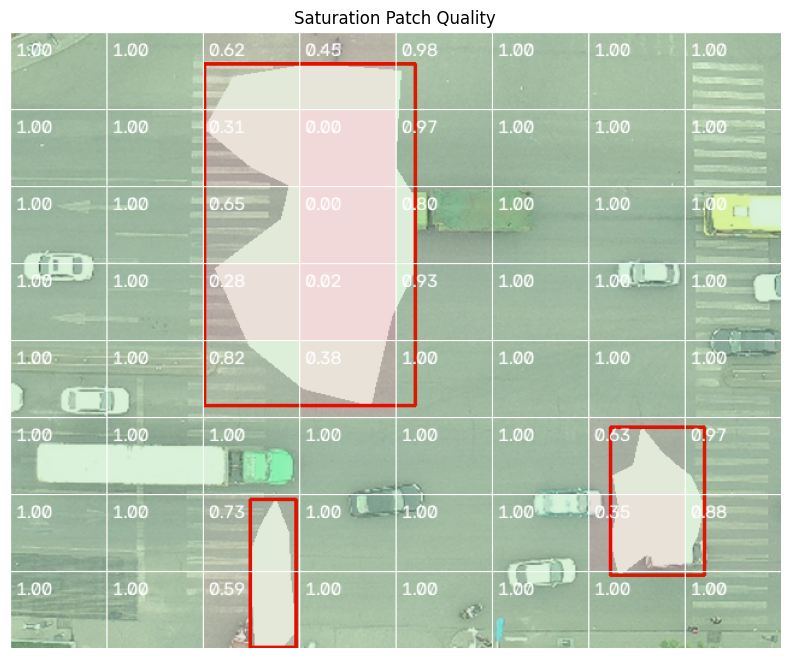

In [29]:
for name in degradation_types:
    title = name.replace("_", " ").title()

    visualize_patch_quality(
        degraded_display[name],
        patch_quality_gt[name],
        title=f"{title} Patch Quality",
    )

### 6.3 Low light

Low light is scored straight from the image instead of from a degradation mask. A patch's quality is 1 minus the fraction of its pixels that fall below a darkness threshold (grayscale). This is an experimental approach to see if we can label low-light images with this instead of doing it manually.

In [30]:
def low_light_patch_quality(image, grid_size=(8, 8), dark_threshold=60):
    """
    Estimate patch quality based on the fraction of very dark pixels.

    Quality:
        1.0 = no dark pixels
        0.0 = all pixels are very dark
    """
    height, width = image.shape[:2]
    grid_h, grid_w = grid_size

    # Convert RGB/BGR image to grayscale.
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Identify very dark pixels.
    dark_mask = gray < dark_threshold

    quality = np.ones((grid_h, grid_w), dtype=np.float32)

    patch_height = height / grid_h
    patch_width = width / grid_w

    for row in range(grid_h):
        for col in range(grid_w):
            y_start = int(row * patch_height)
            y_end = int((row + 1) * patch_height)

            x_start = int(col * patch_width)
            x_end = int((col + 1) * patch_width)

            patch = dark_mask[y_start:y_end, x_start:x_end]

            dark_fraction = patch.mean()

            quality[row, col] = 1.0 - dark_fraction

    return quality

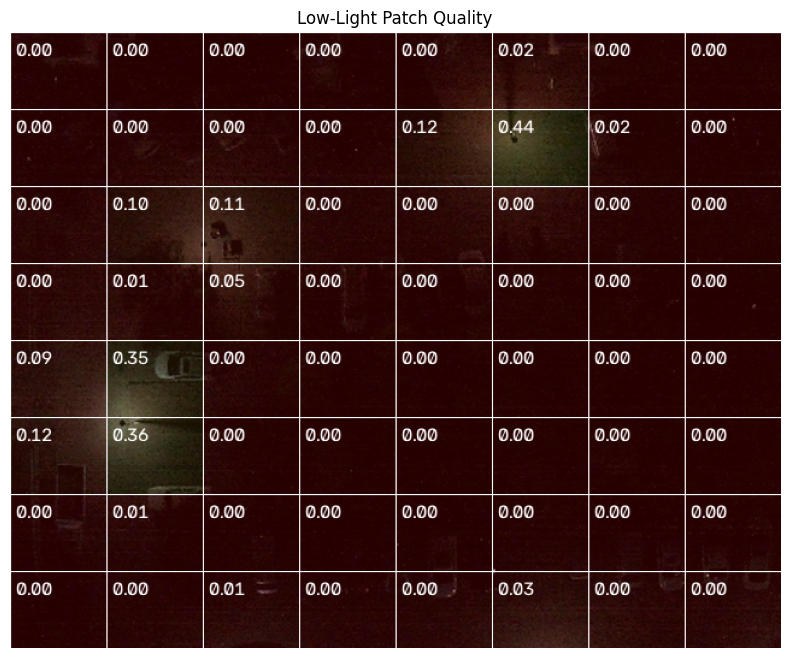

In [31]:
low_light_image = apply_image_crop(cv2.imread("./test_images/00001_rgb.jpg", cv2.IMREAD_COLOR))

quality_gt_low_light = low_light_patch_quality(
    low_light_image,
    grid_size=(8, 8),
    dark_threshold=40,
)

visualize_low_light_quality(
    low_light_image,
    quality_gt_low_light,
    title="Low-Light Patch Quality",
)